# ✈️ Does It Fly? Air or Sea Shipment Classification

Prepared by [AI V&V Lab](https://ai-vnv.kfupm.io/)

Welcome! In this notebook you will:

1. Load a **real public dataset**: ~10,000 international shipments of HIV/AIDS medicines and lab supplies, originally published by USAID.
2. **Train your own small neural network from scratch** — just one hidden layer of 8 neurons — to predict whether a shipment travels **by air** or **by ground/sea**.
3. Use two famous explainability tools — **SHAP** and **LIME** — to open the "black box" and see *why* the network makes each prediction.

This is the *simple-model* twin of the TabICL notebook: no pretrained weights, no downloads — a network small enough that training takes **seconds** on the free Colab CPU.

**How to use this notebook:** run the cells one at a time from top to bottom (click a cell, then press `Shift+Enter`), or use `Runtime ▸ Run all`.

Look out for the 🤔 **Think about it** boxes. They have no single right answer — they are there to make you argue with the machine (and with each other).


## Part 0 — Setup

Colab already has almost everything. We only add `shap` and `lime`, the two explainability libraries.


In [21]:
%pip install -q shap lime

In [22]:
import numpy as np #لإجراء العمليات الرياضية, والتعامل مع المصفوفات
import pandas as pd #لقراءة ملفات csv
import matplotlib.pyplot as plt #لرسم المخططات البيانية

import shap
import lime
import lime.lime_tabular

from sklearn.model_selection import train_test_split #تقسيم البيانات الي تدريب واختبار
from sklearn.preprocessing import StandardScaler #توحيد تقسيم الميزات قبل التدريب
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Make results reproducible (so your neighbor gets the same numbers)
SEED = 42
np.random.seed(SEED)

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


## Part 1 — Meet the data

Each row is one **shipment**: a batch of medicine or lab kits sent from a supplier to a country's health program. The dataset was originally published on the USAID Development Data Library (now retired); we load it from a public mirror on GitHub.


In [23]:
# We try several public copies of the dataset, in order, until one works.
DATA_URLS = [
    "https://raw.githubusercontent.com/jrcinco/supply-chain-shipment-price-data/master/SCMS_Delivery_History_Dataset.csv",
    "https://data.usaid.gov/api/views/a3rc-nmf6/rows.csv?accessType=DOWNLOAD"
] #اذا فشل الاول ينتقل الي الثاني

df = None
for url in DATA_URLS:
    try:#يحاول تحميل ملف csv واذا نجح يتوقف
        df = pd.read_csv(url)
        print("Downloaded", len(df), "shipments with", df.shape[1], "columns")
        break
    except Exception as e:
        print("This source failed, trying the next one...\n  ", url)

if df is None:
    print("All sources failed. Backup plan: search Kaggle for")
    print("'Supply Chain Shipment Pricing Data', download the CSV,")
    print("click the 📁 folder icon on the left of Colab, upload the file,")
    print("and run:  df = pd.read_csv('SCMS_Delivery_History_Dataset.csv')")

Downloaded 10324 shipments with 33 columns


In [24]:
list(df.columns)

['ID',
 'Project Code',
 'PQ #',
 'PO / SO #',
 'ASN/DN #',
 'Country',
 'Managed By',
 'Fulfill Via',
 'Vendor INCO Term',
 'Shipment Mode',
 'PQ First Sent to Client Date',
 'PO Sent to Vendor Date',
 'Scheduled Delivery Date',
 'Delivered to Client Date',
 'Delivery Recorded Date',
 'Product Group',
 'Sub Classification',
 'Vendor',
 'Item Description',
 'Molecule/Test Type',
 'Brand',
 'Dosage',
 'Dosage Form',
 'Unit of Measure (Per Pack)',
 'Line Item Quantity',
 'Line Item Value',
 'Pack Price',
 'Unit Price',
 'Manufacturing Site',
 'First Line Designation',
 'Weight (Kilograms)',
 'Freight Cost (USD)',
 'Line Item Insurance (USD)']

In [25]:
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [26]:
df.tail()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",No,See DN-4307 (ID#:83920),See DN-4307 (ID#:83920),705.79
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,...,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,No,See DN-4313 (ID#:83921),See DN-4313 (ID#:83921),161.71
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,No,Weight Captured Separately,Freight Included in Commodity Cost,5284.04
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,Yes,1392,Freight Included in Commodity Cost,134.03
10323,86823,103-ZW-T30,FPQ-15197,SO-50022,DN-4336,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,36639,72911.61,1.99,0.03,"Cipla, Goa, India",No,Weight Captured Separately,Freight Included in Commodity Cost,85.82


In [27]:
# First look: 5 random shipments
df.sample(5, random_state=SEED) #يعرض 5 صفوف عشوائية
#اذا وجد نص بدل رقم,نحول القيم الي ارقام و اذا حذفناها نفقد جزْ من البيانات واذا كانت كثيرة سيؤثر علي جودة النموذج

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
6584,82275,110-ZM-T30,FPQ-4035,SO-34340,DN-1515,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,30,47227,272972.06,5.78,0.19,"Aurobindo Unit III, India",Yes,4959,9973.51,535.03
1692,11520,117-ET-T01,Pre-PQ Process,SO-1512,DN-517,Ethiopia,PMO - US,From RDC,N/A - From RDC,Air,...,30,535,9095.00,17.00,0.57,Gilead(Nycomed) Oranienburg DE,Yes,33,755.5,14.55
2692,13064,116-ZA-T30,FPQ-14942,SCMS-259075,ASN-32122,South Africa,PMO - US,Direct Drop,DDP,Truck,...,60,25,1246.30,49.85,0.83,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost,1.28
7702,83607,151-NG-T30,FPQ-9432,SO-42803,DN-2769,Nigeria,PMO - US,From RDC,N/A - From RDC,Air Charter,...,30,1161,6431.94,5.54,0.18,"Cipla, Kurkumbh, India",Yes,2566,16532.5,9.02
321,3039,111-MZ-T01,Pre-PQ Process,SCMS-18060,ASN-1651,Mozambique,PMO - US,Direct Drop,EXW,Air,...,100,4200,42.00,0.01,0.00,Inverness Japan,Yes,Weight Captured Separately,Invoiced Separately,0.07


In [28]:
df["Country"].value_counts().head(8)

,count
Country,
South Africa,1406
Nigeria,1194
Côte d'Ivoire,1083
Uganda,779
Vietnam,688
Zambia,683
Haiti,655
Mozambique,631


### 🤔 Think about it

1. Look at the sample rows above. If **you** had to guess whether a shipment went by air or by sea, which columns would you look at first? Why?
2. `Weight (Kilograms)` and `Freight Cost (USD)` sometimes contain *text* instead of numbers (e.g. `"Weight Captured Separately"`). What should we do with those rows — and what could go wrong if we just delete them?


## Part 2 — Explore before you model

Rule #1 of machine learning: **look at your data first.**
Our prediction target: *does the shipment fly?* (Shipment Mode contains "Air" → yes; Truck or Ocean → no).


Shipment Mode
Air            6113
Truck          2830
Air Charter     650
Ocean           371
NaN             360
Name: count, dtype: int64


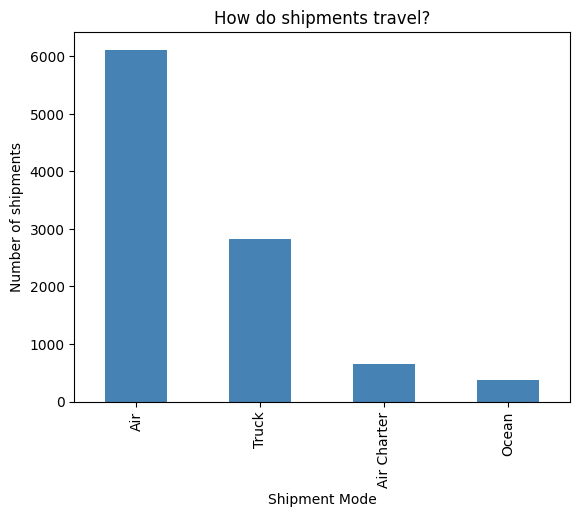

In [29]:
print(df["Shipment Mode"].value_counts(dropna=False)) #يعرض عدد الشحنات لكل وسيلة نقل | value_counts=عدد مرات ظهور كل قيمة

df["Shipment Mode"].value_counts().plot(kind="bar", color="steelblue") #يرسم الbar chart
plt.title("How do shipments travel?") #عنوان الرسم
plt.ylabel("Number of shipments") #يسمي المحور الرأسي
plt.show()

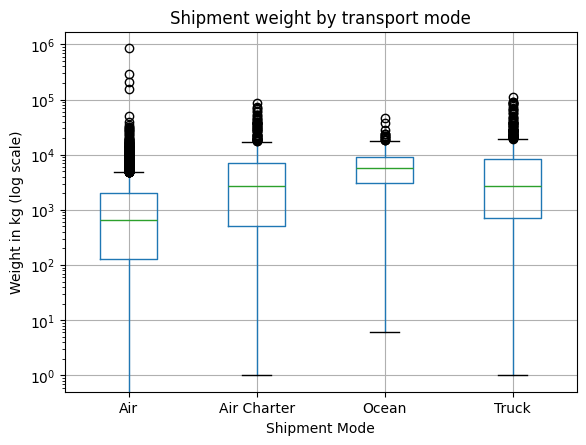

In [30]:
# Does weight relate to how a shipment travels?
tmp = df.copy() #يعرض نسخة من البيانات الأصلية حتى لا نغيّر البيانات الأصلية
tmp["Weight (Kilograms)"] = pd.to_numeric(tmp["Weight (Kilograms)"], errors="coerce") #يحول عمود الوزن الى ارقام
tmp = tmp.dropna(subset=["Weight (Kilograms)", "Shipment Mode"]) #يحذف الصفوف التي لا تحتوي على: الوزن او نوع الشحنة

tmp.boxplot(column="Weight (Kilograms)", by="Shipment Mode")
plt.yscale("log")   # log scale: weights range from 1 kg to many tons
plt.title("Shipment weight by transport mode")
plt.suptitle("")
plt.ylabel("Weight in kg (log scale)")
plt.show()

### 🤔 Think about it

3. Based on the boxplot: are heavy shipments more likely to go by air or by sea? Does that match your real-world intuition (think about the price of air freight)?
4. One transport mode is much more common than the others. If a lazy "model" just always predicted the most common answer, how often would it be right? Our network has to beat that number to be useful!


## Part 3 — Clean the data and build features

Neural networks only eat **numbers**. So we:

1. Keep rows with a known shipment mode and create the target: `flies = 1` (Air / Air Charter) or `0` (Truck / Ocean).
2. Convert messy text like `"Freight Included in Commodity Cost"` into missing values, then drop rows we can't use.
3. Turn categories (country, product group) into 0/1 columns — **one-hot encoding**.


In [31]:
data = df.copy()

# --- 1. Target: does it fly? ---
data = data.dropna(subset=["Shipment Mode"]) #يحذفف جميع الصفوف التي لا تحتوي علي قيمة
data["flies"] = data["Shipment Mode"].str.contains("Air").astype(int) #ينشئ عمود جديد اسمه file ,

# --- 2. Numeric features (coerce text -> NaN, then drop) ---
numeric_features = ["Line Item Quantity", "Line Item Value", "Pack Price",
                    "Unit Price", "Weight (Kilograms)", "Freight Cost (USD)"]
for col in numeric_features:
    data[col] = pd.to_numeric(data[col], errors="coerce") #لو وجد نص يحوله الي nan
#يحاول تحويل القيم الى ارقام
before = len(data) #يحفظ عدد الصفوف قبل الحذف
data = data.dropna(subset=numeric_features) #يحذف أي صف يحتوي على قيمة مفقودة في أي من الميزات الرقمية.
print(f"Dropped {before - len(data)} rows with missing/text values, {len(data)} remain")

# --- 3. Categorical features -> one-hot columns ---
# Keep the 8 most frequent countries, group the rest as 'Other'
top_countries = data["Country"].value_counts().head(8).index #حصل على أكثر 8 دول تكرارًا في البيانات.
data["Country"] = data["Country"].where(data["Country"].isin(top_countries), "Other")  #أي دولة ليست ضمن الثماني الأكثر تكرارًا تصبح: Other

X = pd.get_dummies(data[numeric_features + ["Country", "Product Group"]],
                   columns=["Country", "Product Group"], dtype=float)
y = data["flies"].values

#X = المدخلات (Features).
#y = المخرجات (Target).

feature_names = list(X.columns)
print(f"\nOur model will see {len(feature_names)} features:")
print(feature_names)
print(f"\nTarget balance: {y.mean():.0%} of shipments fly") #يطبع نسبة العينات التي تمثل:

#Air
#مثلاً:
#76%
#أي أن 76% من الشحنات الجوية، و24% برية/بحرية.

Dropped 4000 rows with missing/text values, 5964 remain

Our model will see 20 features:
['Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Weight (Kilograms)', 'Freight Cost (USD)', "Country_Côte d'Ivoire", 'Country_Haiti', 'Country_Mozambique', 'Country_Nigeria', 'Country_Other', 'Country_Tanzania', 'Country_Uganda', 'Country_Vietnam', 'Country_Zambia', 'Product Group_ACT', 'Product Group_ANTM', 'Product Group_ARV', 'Product Group_HRDT', 'Product Group_MRDT']

Target balance: 76% of shipments fly


In [32]:
# Split into train/test. The test shipments stay hidden until grading time.
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=SEED, stratify=y) #اي:80% تدريب 20% اختبار.

print("Training shipments:", len(X_train), "| Test shipments:", len(X_test))

Training shipments: 4771 | Test shipments: 1193


### 🤔 Think about it

5. Why do we set aside a **test set** that the network never sees during training? What would be dishonest about grading the model on shipments it already studied?
6. Sneaky one: `Freight Cost (USD)` is the price paid for the transport... which is only known *after* the transport mode was chosen. Is it fair to let the model use it? (This is called **data leakage** — remember it for Challenge 1!)


## Part 4 — Build and train the neural network

Our network could hardly be simpler:

- **Input layer**: one neuron per feature (20 of them)
- **One hidden layer**: 8 neurons with ReLU activation
- **Output**: the probability that the shipment flies

One detail: features like `Weight` (thousands of kg) and `Unit Price` (a few dollars) live on wildly different scales, and neural networks hate that. So we bundle a **scaler** (which standardizes every feature) and the network into a single pipeline — scaling happens automatically inside the model.

Training = showing the network the training shipments over and over (each full pass is an **epoch**) while it nudges its weights to reduce its mistakes.


Training finished after 204 epochs


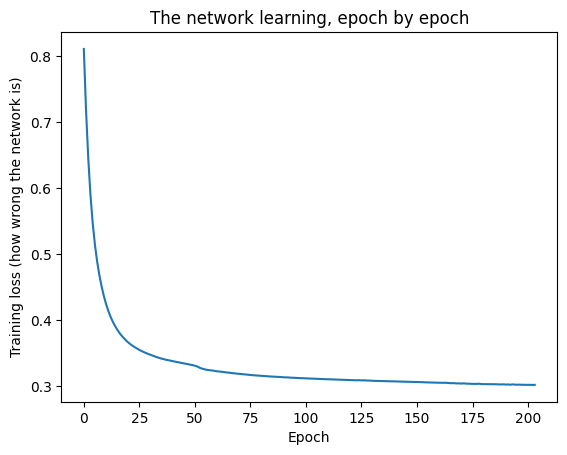

In [33]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(8,), max_iter=300, random_state=SEED)), #ذلك نستخدم: StandardScaler ليجعل جميع الميزات تقريبًا بنفس المقياس.
]) #طبقة مخفية واحدة بداخلها 8 Neurons
# أقصى عدد للتدريب: 300 Epoch إذا انتهى التعلم قبلها سيتوقف

model.fit(X_train, y_train)   # takes a few seconds هنا يبدأ التعلم الحقيقي.
print("Training finished after", model.named_steps["mlp"].n_iter_, "epochs")

plt.plot(model.named_steps["mlp"].loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Training loss (how wrong the network is)")
plt.title("The network learning, epoch by epoch")
plt.show()

### 🤔 Think about it

7. Describe the loss curve in your own words. Where does the network learn fastest? Why do you think progress slows down?
8. The curve shows the error on *training* data only. Could the curve keep going down while the network actually gets *worse* on new shipments? What is that called? (Hint: it's like memorizing the answer key instead of learning the subject.)


## Part 5 — How good is it, really?

Accuracy alone can lie (remember question 4!). Let's compare against the lazy baseline and look at the **confusion matrix** — a table of what the model got right and wrong, per class.


Lazy baseline (always guess the majority): 75.8%
Neural network accuracy on unseen shipments: 84.0%


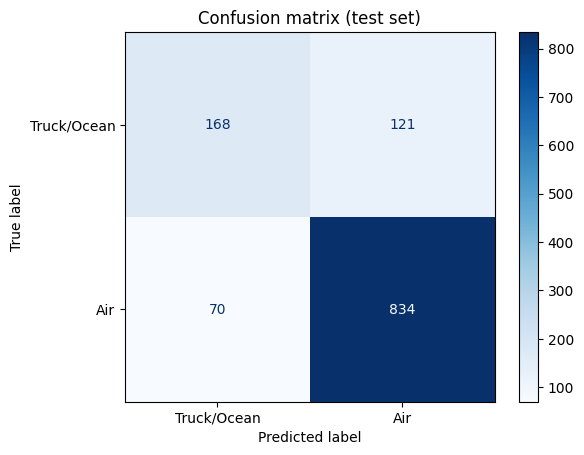

In [34]:
probs = model.predict_proba(X_test)[:, 1]    # probability that each shipment flies
preds = (probs > 0.5).astype(int)

baseline = max(y_test.mean(), 1 - y_test.mean()) #أكبر نسبة لفئة موجودة في البيانات.
print(f"Lazy baseline (always guess the majority): {baseline:.1%}")
print(f"Neural network accuracy on unseen shipments: {accuracy_score(y_test, preds):.1%}") #يقارن بين التوقع الحقيقي وتوقع النموذج

ConfusionMatrixDisplay.from_predictions(
    y_test, preds, display_labels=["Truck/Ocean", "Air"], cmap="Blues")
plt.title("Confusion matrix (test set)")
plt.show()

### 🤔 Think about it

9. Did the network beat the lazy baseline? By how much?
10. Look at the confusion matrix. Which mistake does the model make more often: calling a truck/ship shipment "air", or the reverse? If each wrong "air" guess wasted money on unnecessary air freight, which error would a logistics manager care about more?


## Part 6 — SHAP: opening the black box (globally)

The network works — but *why*? Even our tiny network has ~180 weights; nobody can read its reasoning directly.

**SHAP** (SHapley Additive exPlanations) borrows an idea from game theory: treat each feature as a *player on a team*, and fairly split the "credit" for each prediction among them. A feature's SHAP value tells you how much it pushed one prediction toward *plane* (positive) or toward *truck/ship* (negative).

Because scaling lives *inside* the pipeline, SHAP sees features in their **real units** — kilograms and dollars.


In [35]:
predict_fly = lambda x: model.predict_proba(np.asarray(x))[:, 1]

background = shap.kmeans(X_train, 25)        # 25 'typical' shipments as reference
explainer = shap.KernelExplainer(predict_fly, background) #المسؤول عن حساب SHAP Valueys

N_EXPLAIN = 100 #سنفسر 100 عينة فقط
X_explain = X_test[:N_EXPLAIN] # اول 100 شحنة من test set
shap_values = explainer.shap_values(X_explain, nsamples=200)   # ~1 minute #كلما زاد الرقم صار أبطأ
print("Explained", N_EXPLAIN, "shipments")

  0%|          | 0/100 [00:00<?, ?it/s]

Explained 100 shipments


/tmp/ipykernel_2371/4008317268.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, feature_names=feature_names)


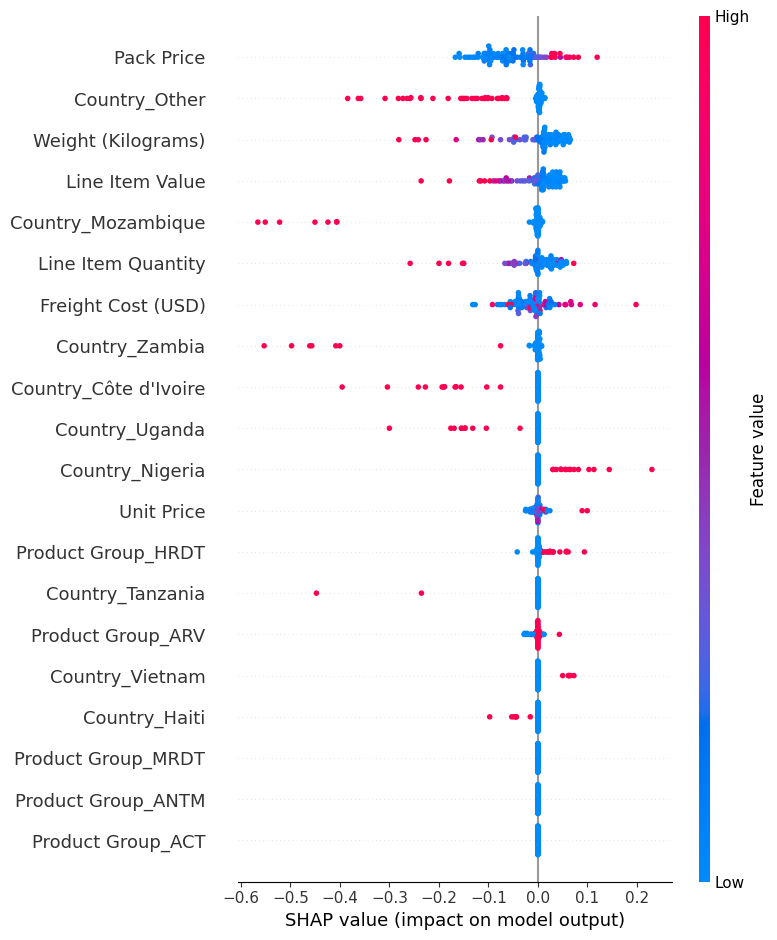

In [36]:
# The beeswarm plot: every dot is one shipment.
# Right of center = pushed the prediction toward "Air", left = toward "Truck/Ocean".
# Red = that feature's value was high, blue = low.
shap.summary_plot(shap_values, X_explain, feature_names=feature_names)

/tmp/ipykernel_2371/2564061805.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, feature_names=feature_names, plot_type="bar")


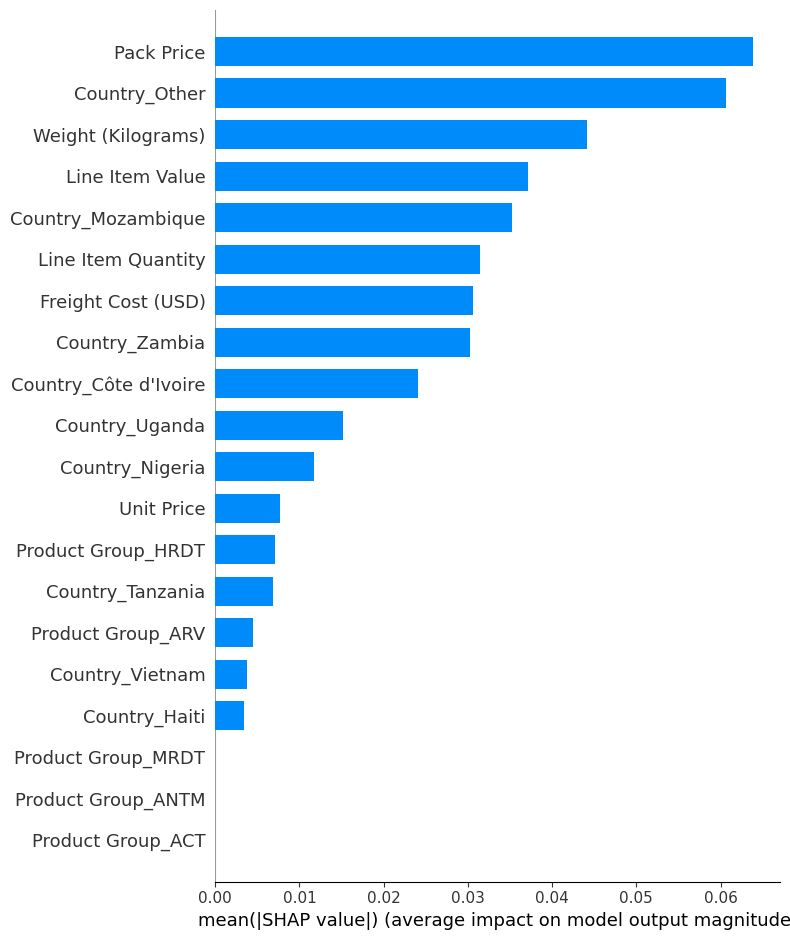

In [37]:
# Same information, averaged: which features matter most overall?
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, plot_type="bar")
#يعرض كيف بدأـ التوقعات من base value ثم كيف دفعت كل feature نحو التنبؤ

Model's predicted probability of flying: 0.74
Actually flew: no


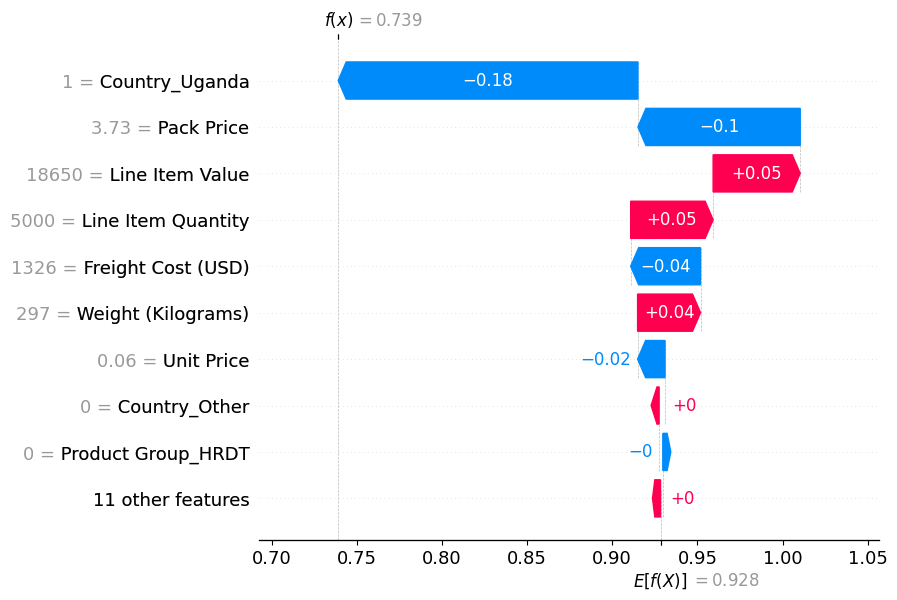

In [42]:
# Zoom in on ONE shipment: a waterfall of how each feature pushed the prediction
i = 3  # <-- try changing this to any number from 0 to N_EXPLAIN-1
explanation = shap.Explanation(values=shap_values[i],
                               base_values=explainer.expected_value,
                               data=X_explain[i],
                               feature_names=feature_names)
print(f"Model's predicted probability of flying: {probs[i]:.2f}")
print(f"Actually flew: {'yes' if y_test[i] == 1 else 'no'}")
shap.plots.waterfall(explanation)

### 🤔 Think about it

11. According to the bar chart, what are the top 3 features the network relies on? Do they match what you guessed back in question 1?
12. In the beeswarm plot, find `Weight (Kilograms)`. Do high weights (red dots) push toward air or toward truck/ship? Does the *model's* logic agree with *your* logic from the boxplot?
13. Change `i` in the waterfall cell to look at a few different shipments. Find one where two features push in *opposite* directions. How does the model settle the argument?


## Part 7 — LIME: a second opinion (locally)

**LIME** (Local Interpretable Model-agnostic Explanations) takes a different approach: to explain one shipment, it creates thousands of slightly modified copies of it, asks the network about each copy, and fits a simple rule-based approximation that's valid *near that one shipment*.

Same goal as SHAP, different philosophy. Let's see if they agree.


In [39]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=["Truck/Ocean", "Air"],
    mode="classification",
    random_state=SEED)

In [40]:
i = 0  # same shipment we examined with SHAP — change it to explore!
exp = lime_explainer.explain_instance(
    X_explain[i], model.predict_proba, num_features=8)
exp.show_in_notebook(show_table=True)

*How to read it:* orange bars are features pushing this prediction toward **Air**, blue bars push toward **Truck/Ocean**. Notice LIME speaks in human-readable rules like `Weight (Kilograms) > 831` — real units, because scaling is hidden inside our pipeline.

### 🤔 Think about it

14. Compare LIME's explanation of shipment `i = 0` with SHAP's waterfall for the same shipment. Do they name the same top features? Do they ever disagree on the *direction* of a feature's push?
15. Run the LIME cell twice **after removing** `random_state=SEED` from the explainer. Do you get the exact same explanation both times? What does that tell you about how much to trust a single explanation?
16. A hospital logistics officer asks: *"Why did your system route my vaccine shipment by sea?"* Which explanation would you show them — SHAP or LIME — and how would you explain it in one sentence of plain English?


## Part 8 — Challenges 🏆

Now it's your turn. Each challenge only requires editing and re-running cells above.

**Challenge 1 — Catch the cheater.** In question 6 we suspected `Freight Cost (USD)` might be data leakage. Remove it from `numeric_features` in Part 3 and re-run everything. How much does test accuracy drop? Which feature becomes most important in SHAP instead? Which model would be more *useful in real life* — the one with or without freight cost?

**Challenge 2 — Architect.** Change `hidden_layer_sizes`: try `(2,)`, then `(64, 64, 64)`. Watch the loss curve, the accuracy, and the training time. Does bigger always mean better on this dataset?

**Challenge 3 — Do we even need a neural network?** Swap the `MLPClassifier` for `LogisticRegression` (from `sklearn.linear_model`) inside the pipeline. Compare accuracy. When might the simplest model be the smartest choice?

**Challenge 4 — Detective.** Find test shipments the model got *wrong* (`np.where(preds != y_test)[0]`), pick one with an index below `N_EXPLAIN`, and study its SHAP waterfall and LIME explanation. Can you form a theory of why the model was fooled?

**Challenge 5 — Your own question.** The dataset has many columns we ignored (vendor, dosage form, manufacturing site...). Add one to the features in Part 3. Does it help? Does SHAP think it matters?

---

## What you learned

- Real data is messy; cleaning it is half the job.
- A tiny neural network — 8 hidden neurons, trained in seconds — can beat a naive baseline on a real logistics problem.
- Accuracy is not the whole story — baselines and confusion matrices keep you honest.
- SHAP and LIME let you interrogate a black-box model: SHAP gives fair global + local credit assignment; LIME builds a simple local imitation.
- Explanations are not just nice-to-have: in medicine supply chains, someone has to *justify* every routing decision.

**Credits:** Dataset — USAID, *Supply Chain Shipment Pricing Data* (public domain; originally on the USAID Development Data Library, mirrored [on GitHub](https://github.com/jrcinco/supply-chain-shipment-price-data)).
